<a href="https://colab.research.google.com/github/anniiexp/MAT422/blob/main/2_4_MLE_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 - Section 2.4: MLE Linear Regressiom

In [10]:
import numpy as np
import matplotlib.pyplot as plt

## Topics:

*   MLE For Random Samples
*   Linear Regression

# 2.4.1 MLE For Random Samples

MLE stands for Maximum Likelihood Estimation, and is a method for estimating an unknown population parameter using observed data. It chooses the parameter value that makes the observed sample most likely under an assumed probability model.
A random sample, written as $X_1,\ldots,X_n$, consists of independent
observations from the same distribution.
For example, suppose we flip a coin 10 times and observe 7 heads.
The MLE of the probability of heads is:

$$
\hat{p} = \frac{\text{Number of heads}}{\text{Number of flips}}
= \frac{7}{10} = 0.7
$$

This means our estimated probability of heads is 70%.

In [11]:
# 1 means heads, 0 means tails
sample = [1, 1, 0, 1, 1, 0, 1, 1, 0, 1]

heads = sum(sample)
tails = len(sample) - heads
p_hat = heads / len(sample)

print(f"MLE probability of heads: {p_hat:.2f}")

for p in [0.5, 0.7, 0.9]:
    likelihood = p**heads * (1 - p)**tails
    print(f"p = {p:.1f}: likelihood = {likelihood:.6f}")

MLE probability of heads: 0.70
p = 0.5: likelihood = 0.000977
p = 0.7: likelihood = 0.002224
p = 0.9: likelihood = 0.000478


Among the probabilities compared, $p = 0.7$ gives the highest likelihood for our observed sequence. This agrees with the MLE: 7 heads out of 10 flips gives an estimated probability of heads of 70%.

For the visual below, the likelihood curve reaches its highest point at $p = 0.7$.
This shows that a 70% probability of heads makes our observed sequence
of 7 heads and 3 tails most likely, so the MLE is $\hat{p} = 0.7$.

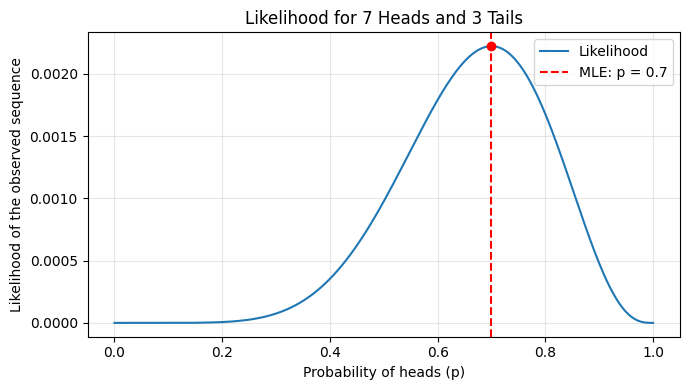

In [12]:
# Possible probabilities of heads
p = np.linspace(0, 1, 501)

# Likelihood of the observed sequence: 7 heads and 3 tails
likelihood = p**7 * (1 - p)**3

plt.figure(figsize=(7, 4))
plt.plot(p, likelihood, label="Likelihood")
plt.axvline(0.7, color="red", linestyle="--", label="MLE: p = 0.7")
plt.scatter(0.7, 0.7**7 * 0.3**3, color="red", zorder=3)

plt.title("Likelihood for 7 Heads and 3 Tails")
plt.xlabel("Probability of heads (p)")
plt.ylabel("Likelihood of the observed sequence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2.4.2 Linear Regression

Linear Regression describes the relationship between an input variable $x$ and an outcome $y$ by fitting a straight line to the data. For example, we can use hours studied ($x$) to predict a student's exam score ($y$). The predicted score is:

$$
\hat{y} = b_0 + b_1x
$$

Here, $b_0$ is the intercept, or predicted score when $x = 0$,
and $b_1$ is the slope, or predicted change in score for each
additional hour studied.

The least-squares method chooses the line that minimizes the sum
of squared differences between observed and predicted scores:

$$
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Fitted equation: predicted score = 43.70 + 7.10 × hours
Predicted score for 4 hours: 72.10
Squared error using regression: 9.90
Squared error using only the mean: 514.00


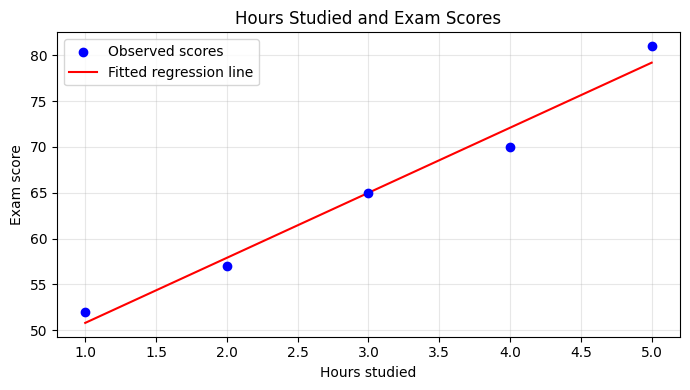

In [13]:
# example data: hours studied and exams cores
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([52, 57, 65, 70, 81], dtype=float)

# calculate the least-squares slope and intercept
slope = np.sum((x - x.mean()) * (y - y.mean())) / np.sum(
    (x - x.mean())**2
)
intercept = y.mean() - slope * x.mean()

# predicted scores and sum of errors
y_pred = intercept + slope * x
sse = np.sum((y - y_pred)**2)

# compare with predicting the mean score for everyone
sse_mean = np.sum((y - y.mean())**2)

print(f"Fitted equation: predicted score = {intercept:.2f} + {slope:.2f} × hours")
print(f"Predicted score for 4 hours: {intercept + slope * 4:.2f}")
print(f"Squared error using regression: {sse:.2f}")
print(f"Squared error using only the mean: {sse_mean:.2f}")

# plot the observations and fitted line
plt.figure(figsize=(7, 4))
plt.scatter(x, y, color="blue", label="Observed scores", zorder=3)
plt.plot(x, y_pred, color="red", label="Fitted regression line")

plt.title("Hours Studied and Exam Scores")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The fitted equation is $\hat{y} = 43.7 + 7.1x$. Each additional hour
studied is associated with a predicted increase of 7.1 score points.
For 4 hours of studying, the predicted score is 72.1.

The regression line has a sum of squared errors of 9.90, compared
with 514.00 when predicting the mean score for everyone. This shows
that using hours studied improves the fit for these example data.

This relationship does not by itself prove that studying an extra
hour causes a 7.1-point increase.

# Reflection



*   MLE for random samples: Used 7 heads in 10 coin flips to estimate the probability of heads as 0.7. Compared likelihood values and plotted the likelihood curve, which peaked at 0.7. This showed how MLE chooses the parameter value that makes the observed sample most likely.  
*   Linear regression: Used hours studied and exam scores to fit a straight line. The slope showed a predicted increase of 7.1 score points for each additional hour studied. The graph and squared error of 9.90, compared with 514.00 when predicting only the mean, showed that the regression line fit these data better.

